In [1]:
import torch
import numpy as np

print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

PyTorch version: 2.12.0+cpu
GPU available: False
Device: cpu
Using device: cpu


In [5]:
# Tensors
t1 = torch.tensor([1.0, 2.0, 3.0])
t2 = torch.zeros(3, 4)
t3 = torch.ones(2, 3)
t4 = torch.randn(3, 3)
t5 = torch.arange(0, 10, 2)

print(t1)
print(t2)
print(t3)
print(t4)
print(t5)

# Converting fron numpy
arr = np.array([1.0, 2.0, 3.0])
t_from_np = torch.from_numpy(arr)
print(t_from_np)

# Convert to numpy
back_to_np = t1.numpy()
print(back_to_np)

tensor([1., 2., 3.])
tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])
tensor([[1., 1., 1.],
        [1., 1., 1.]])
tensor([[-1.1004, -0.6242, -0.0087],
        [ 0.8628, -0.1060, -0.5457],
        [-0.4979, -0.8412, -1.5794]])
tensor([0, 2, 4, 6, 8])
tensor([1., 2., 3.], dtype=torch.float64)
[1. 2. 3.]


In [7]:
# Tensor operations
a = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
b = torch.tensor([[5.0, 6.0], [7.0, 8.0]])

print(a + b)
print(a * b)
print(a @ b)
print(a.T)
print(a.sum())
print(a.mean(dim = 0))
print(a.reshape(1, 4))
print(a.shape)

tensor([[ 6.,  8.],
        [10., 12.]])
tensor([[ 5., 12.],
        [21., 32.]])
tensor([[19., 22.],
        [43., 50.]])
tensor([[1., 3.],
        [2., 4.]])
tensor(10.)
tensor([2., 3.])
tensor([[1., 2., 3., 4.]])
torch.Size([2, 2])


In [8]:
# Autograd

# requires_grad = True tells Pytorch to track operations on the tensor
x = torch.tensor(3.0, requires_grad = True)

# Define a simple function
y = x**2 + 2*x + 1
print(f"y = {y}")

# Compute gradient dy/dx
y.backward()
print(f"dy/dx at x = 3: {x.grad}")

y = 16.0
dy/dx at x = 3: 8.0


In [10]:
# More practice

# Simulate a simple linear model: output = weight * input + bias
weight = torch.tensor(2.0, requires_grad = True)
bias = torch.tensor(1.0, requires_grad = True)

# Input and target
x = torch.tensor(5.0)
target = torch.tensor(12.0)

# Forward pass
output = weight * x + bias
print(f"Output: {output}")

# Loss (MSE)
loss = (output - target)**2
print(f"Loss: {loss}")

# Backwards pass, compute gradients
loss.backward()
print(f"d(loss)/d(weight): {weight.grad}")
print(f"d(loss)/d(bias): {bias.grad}")

# Hand calculations to confirm
# output = 2 * 5 + 1 = 11
# loss = (11 - 12) ^ 2 = 1
# d(loss)/d(weight) = 2(output - target) * x = 2 * (-1) * 5 = -10 (since we take partial derivative of output, chain rule)
# d(loss) / d(bias) = 2 * (output - target) * 1 = 2 * (-1) = -2

Output: 11.0
Loss: 1.0
d(loss)/d(weight): -10.0
d(loss)/d(bias): -2.0


In [12]:
# Gradient descent by hand

# Simple linear reg from scratch
torch.manual_seed(42)

# True relationship: y = 3x + 2
X = torch.randn(100, 1)
y = 3 * X + 2 + torch.randn(100, 1) * 0.1 # Add some small noise

# Initialize weights randomly
weight = torch.randn(1, requires_grad = True)
bias = torch.randn(1, requires_grad = True)

learning_rate = 0.1
losses = []

for epoch in range(100):
    # Forward pass
    y_pred = weight * X + bias

    # Loss (MSE)
    loss = ((y_pred - y)**2).mean()
    losses.append(loss.item())

    # Backward pass
    loss.backward()

    # Update weights (gradient descent)
    with torch.no_grad(): # dont autograd track these operations
        weight -= learning_rate * weight.grad
        bias -= learning_rate * bias.grad

    # Zero gradients
    weight.grad.zero_()
    bias.grad.zero_()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}: loss = {loss.item():.4f}, "
              f"weight = {weight.item():.3f}, bias = {bias.item():.3f}")

print(f"\nFinal: weight = {weight.item():.3f} (true: 3.0), bias = {bias.item():.3f} (true 2.0)")

Epoch 0: loss = 12.1962, weight = 0.924, bias = 0.260
Epoch 10: loss = 0.1235, weight = 2.786, bias = 1.849
Epoch 20: loss = 0.0089, weight = 2.978, bias = 1.990
Epoch 30: loss = 0.0078, weight = 2.999, bias = 2.003
Epoch 40: loss = 0.0078, weight = 3.001, bias = 2.003
Epoch 50: loss = 0.0078, weight = 3.001, bias = 2.004
Epoch 60: loss = 0.0078, weight = 3.001, bias = 2.004
Epoch 70: loss = 0.0078, weight = 3.001, bias = 2.004
Epoch 80: loss = 0.0078, weight = 3.001, bias = 2.004
Epoch 90: loss = 0.0078, weight = 3.001, bias = 2.004

Final: weight = 3.001 (true: 3.0), bias = 2.004 (true 2.0)


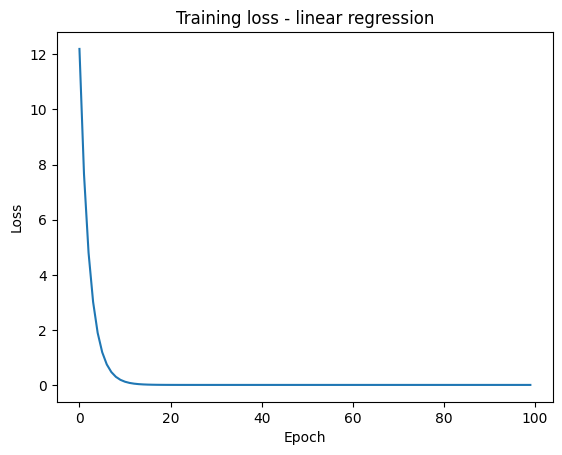

In [13]:
# Plot the loss curve
import matplotlib.pyplot as plt

plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training loss - linear regression')
plt.show()

## Day 1 Key Concepts

**Tensor**: PyTorch's array - like numpy but GPU-compatible and differentiable

**requires_grad**: tells PyTorch to track operations for gradient computation

**Forward pass** computing output from input through the model

**Loss**: a number measuring how wrong the model's predictions are (lower = better)

**Backward pass (.backward())**: automatically computes gradients of loss with respect to all tracked tensors

**Gradient descent**: nudge weights in the direction that reduces loss, scaled by learning_rate

**grad.zero_()**: must zero gradients each step - PyTorch accumulates gradients by default

**torch.no_grad()**: used when updating weights - don't want PyTorch tracking this update step

## Day 2 Goals
Move from manual gradient descent to PyTorch's proper building blocks: nn.Module, nn.Linear, loss functions, optimizers. Building a simple classifier to learn and practice

In [2]:
import torch
import torch.nn as nn

# A single linear layer: y = Wx + b
linear_layer = nn.Linear(in_features = 1, out_features = 1)

# randomly initialized
print(linear_layer.weight)
print(linear_layer.bias)

# test
x = torch.tensor([[5.0]])
output = linear_layer(x)
print(output)

Parameter containing:
tensor([[-0.6369]], requires_grad=True)
Parameter containing:
tensor([0.7754], requires_grad=True)
tensor([[-2.4090]], grad_fn=<AddmmBackward0>)


In [3]:
# Building a model class
# (for anything more than a single layer, define a custom class inheriting from nn.Module
class SimpleLinearModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)

    def forward(self, x):
        return self.linear(x)

model = SimpleLinearModel()
print(model)

# See the parameters
for name, param in model.named_parameters():
    print(name, param.data)

SimpleLinearModel(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)
linear.weight tensor([[0.8238]])
linear.bias tensor([0.7357])


In [5]:
# Redo Day 1's lin reg using nn.Module + optimizer
torch.manual_seed(42)

# Same data as day 1
X = torch.randn(100, 1)
y = 3 * X + 2 + torch.randn(100, 1) * 0.1

# Model
model = SimpleLinearModel()

# Loss function (built-in instead of manual MSE)
loss_fn = nn.MSELoss()

# Optimizer (replaces manual change of weight -= learning rate * gradient
optimizer = torch.optim.SGD(model.parameters(), lr = 0.1)

losses = []
for epoch in range(100):
    # forward pass
    y_pred = model(X)

    # loss
    loss = loss_fn(y_pred, y)
    losses.append(loss.item())

    # backward pass
    optimizer.zero_grad()
    loss.backward()

    # update weights
    optimizer.step()

    if epoch % 10 == 0:
        w = model.linear.weight.item()
        b = model.linear.bias.item()
        print(f"Epoch {epoch}: loss = {loss.item():.4f}, weight = {w:.3f}, bias = {b:.3f}")

print(f"\nFinal weight: {model.linear.weight.item():.3f} (true: 3.0)")
print(f"\nFinal bias: {model.linear.bias.item():.3f} (true: 2.0)")

Epoch 0: loss = 7.8530, weight = 0.981, bias = 1.104
Epoch 10: loss = 0.0921, weight = 2.778, bias = 1.940
Epoch 20: loss = 0.0088, weight = 2.976, bias = 2.000
Epoch 30: loss = 0.0078, weight = 2.998, bias = 2.004
Epoch 40: loss = 0.0078, weight = 3.001, bias = 2.004
Epoch 50: loss = 0.0078, weight = 3.001, bias = 2.004
Epoch 60: loss = 0.0078, weight = 3.001, bias = 2.004
Epoch 70: loss = 0.0078, weight = 3.001, bias = 2.004
Epoch 80: loss = 0.0078, weight = 3.001, bias = 2.004
Epoch 90: loss = 0.0078, weight = 3.001, bias = 2.004

Final weight: 3.001 (true: 3.0)

Final bias: 2.004 (true: 2.0)


In [7]:
# Building a multi-layer network (multi-layer perceptron)
class SimpleMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

model = SimpleMLP(input_dim = 10, hidden_dim = 32, output_dim = 2)
print(model)

# test with fake input
x = torch.randn(5, 10) # batch of 5 samples, 10 features each
output = model(x)
print(f"Output shape: {output.shape}") # (5, 2)

SimpleMLP(
  (fc1): Linear(in_features=10, out_features=32, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=32, out_features=2, bias=True)
)
Output shape: torch.Size([5, 2])


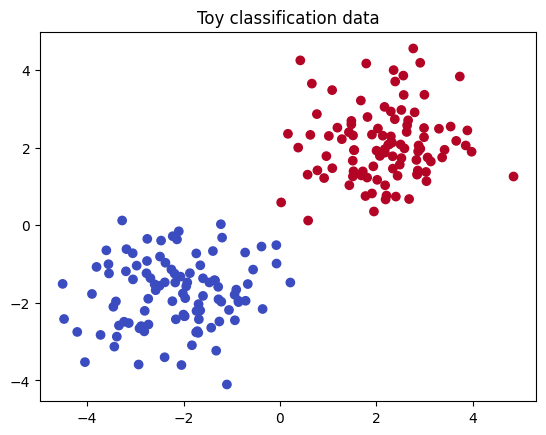

Epoch 0: loss = 0.7116, accuracy = 47.00%
Epoch 20: loss = 0.0578, accuracy = 99.50%
Epoch 40: loss = 0.0112, accuracy = 100.00%
Epoch 60: loss = 0.0057, accuracy = 100.00%
Epoch 80: loss = 0.0040, accuracy = 100.00%
Epoch 100: loss = 0.0031, accuracy = 100.00%
Epoch 120: loss = 0.0024, accuracy = 100.00%
Epoch 140: loss = 0.0020, accuracy = 100.00%
Epoch 160: loss = 0.0017, accuracy = 100.00%
Epoch 180: loss = 0.0014, accuracy = 100.00%


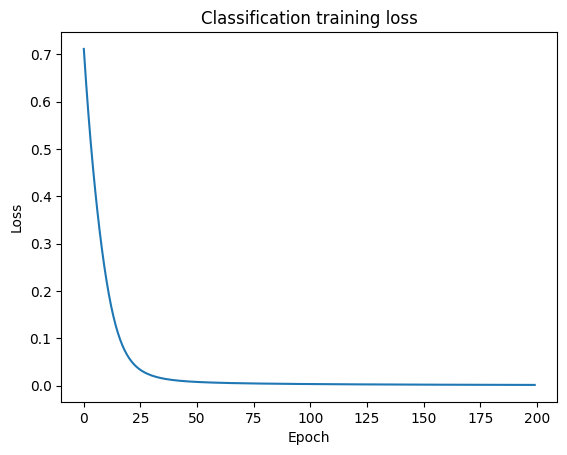

In [11]:
# build a simple classifier on toy data
import matplotlib.pyplot as plt

torch.manual_seed(42)

# generate toy classification data, 2 blobs
n_samples = 200
class0 = torch.randn(n_samples // 2, 2) + torch.tensor([-2.0, -2.0])
class1 = torch.randn(n_samples // 2, 2) + torch.tensor([2.0, 2.0])

X = torch.cat([class0, class1], dim = 0)
y = torch.cat([torch.zeros(n_samples // 2), torch.ones(n_samples // 2)]).long()

# Visualize
plt.scatter(X[:, 0], X[:, 1], c = y, cmap = 'coolwarm')
plt.title('Toy classification data')
plt.show()

# Model
class Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 16)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, 2)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

model = Classifier()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01)

losses = []
for epoch in range(200):
    optimizer.zero_grad()

    outputs = model(X)
    loss = loss_fn(outputs, y)
    losses.append(loss.item())

    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        # compute accuracy
        predictions = outputs.argmax(dim = 1)
        accuracy = (predictions == y).float().mean()
        print(f"Epoch {epoch}: loss = {loss.item():.4f}, accuracy = {accuracy.item():.2%}")

plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Classification training loss')
plt.show()

## Day 2 Key Concepts

**nn.Module**: base class for all PyTorch models, define __init__ (layers) and forward (data flow)

**nn.Linear(in, out)**: a fully-connected layer, computes Wx + b

**Activation functions (like ReLU)**: introduce non-linearity. Without these, stacked linear layers collapse to one linear layer

**nn.CrossEntropyLoss**: standard loss for multi-class classification, internally combines softmax and negative log likelihood

**SGD vs Adam**: SGD takes fixed-size teps in the gradient direction, Adam adapts step size per parameter and usually converges faster (most modern training uses Adam or some variant)

**model.parameters()**: returns all trainable weights/biases in the model, used by optimizer to know what to update

**argmax(dim = 1)**: converts class probablilities/scores into a predicted class label (the index with the highest value)

## Day 3: Autencoders
Goal: build and train a basic autoencoder on MNIST, understand the encoder/decoder architechture and what a latent space is.

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 721kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 7.70MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.51MB/s]


Dataset size: 60000
Batches per epoch: 235


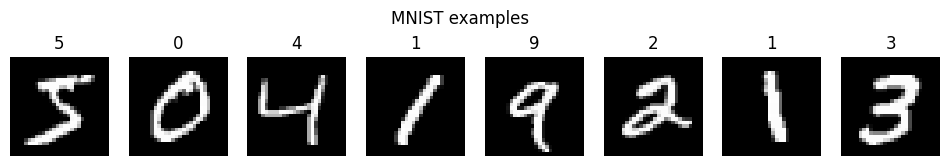

In [2]:
# Load MNIST
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, ), (0.5, ))])

train_dataset = torchvision.datasets.MNIST(
    root = './data_mnist',
    train = True,
    download = True,
    transform = transform)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size = 256,
    shuffle = True)

print(f"Dataset size: {len(train_dataset)}")
print(f"Batches per epoch: {len(train_loader)}")

# visualize some examples
fig, axes = plt.subplots(1, 8, figsize = (12, 2))
for i in range(8):
    img, label = train_dataset[i]
    axes[i].imshow(img.squeeze(), cmap = 'gray')
    axes[i].set_title(str(label))
    axes[i].axis('off')
plt.suptitle('MNIST examples')
plt.show()

In [6]:
# build autoencoder
class Autoencoder(nn.Module):
    def __init__(self, input_dim = 784, hidden_dim = 256, latent_dim = 32):
        super().__init__()

        # Encoder: compress input down to latent space
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim),
            nn.ReLU())

        # Decoder: reconstruct input from latent space
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Tanh())

    def forward(self, x):
        # flatten image: (batch, 1, 28, 28) -> (batch, 784)
        x = x.view(x.size(0), -1)
        # encode and decode
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)

        return reconstructed, latent

model = Autoencoder()
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=32, bias=True)
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=784, bias=True)
    (3): Tanh()
  )
)
Total parameters: 419,120


Epoch 1 / 10: loss = 0.1568
Epoch 2 / 10: loss = 0.0699
Epoch 3 / 10: loss = 0.0609
Epoch 4 / 10: loss = 0.0569
Epoch 5 / 10: loss = 0.0541
Epoch 6 / 10: loss = 0.0519
Epoch 7 / 10: loss = 0.0499
Epoch 8 / 10: loss = 0.0483
Epoch 9 / 10: loss = 0.0468
Epoch 10 / 10: loss = 0.0456


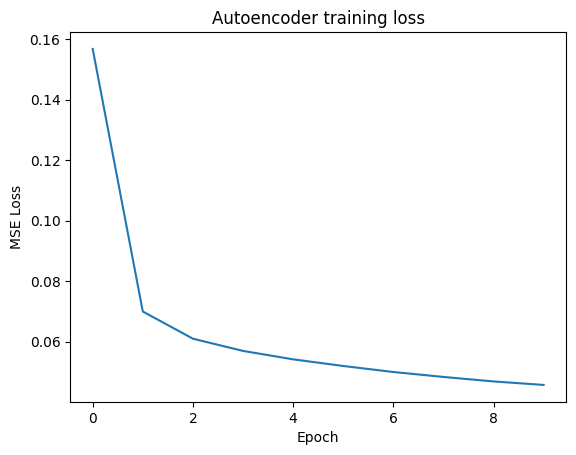

In [7]:
# train autoencoder

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# MSE loss (want output to match input)
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)

n_epochs = 10
train_losses = []

for epoch in range(n_epochs):
    epoch_loss = 0
    for batch_imgs, _ in train_loader: # _ ignores labels since not needed
        # move to device
        batch_imgs = batch_imgs.to(device)

        # forward pass
        reconstructed, latent = model(batch_imgs)

        # target is same as input (flattened)
        target = batch_imgs.view(batch_imgs.size(0), -1)
        loss = loss_fn(reconstructed, target)

        # backwards pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch + 1} / {n_epochs}: loss = {avg_loss:.4f}")

plt.plot(train_losses)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Autoencoder training loss')
plt.show()

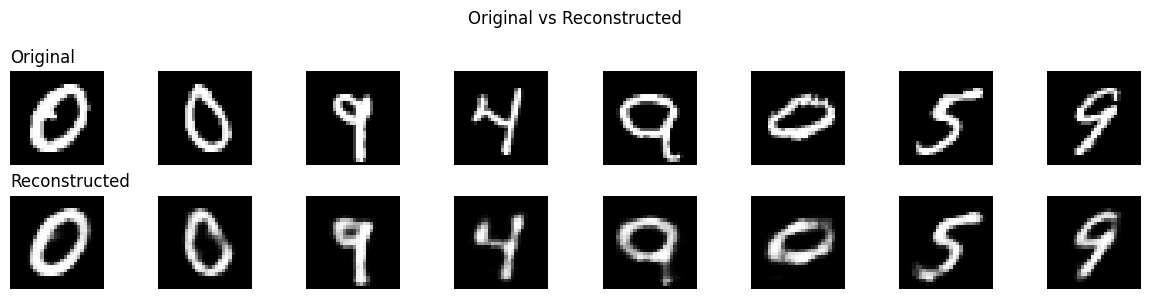

In [8]:
# visualize reconstructions

model.eval() # turn off dropout/batchnorm (not used here, but a good habit)

with torch.no_grad(): # no gradients needed for visualization
    # take a batch of test imgs
    test_imgs, test_labels = next(iter(torch.utils.data.DataLoader(
        torchvision.datasets.MNIST(
            root = './data_mnist', train = False, download = True, transform = transform),
        batch_size = 8, shuffle = True)))

    test_imgs = test_imgs.to(device)
    reconstructed, latent = model(test_imgs)

    # reshape back to 28x28 for display
    original = test_imgs.cpu().squeeze().numpy()
    recon = reconstructed.cpu().view(-1, 28, 28).numpy()

fig, axes = plt.subplots(2, 8, figsize = (12, 3))
for i in range(8):
    axes[0, i].imshow(original[i], cmap = 'gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('Original', loc = 'left')

    axes[1, i].imshow(recon[i], cmap = 'gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('Reconstructed', loc = 'left')

plt.suptitle('Original vs Reconstructed')
plt.tight_layout()
plt.show()

Latent shape: (10000, 32)


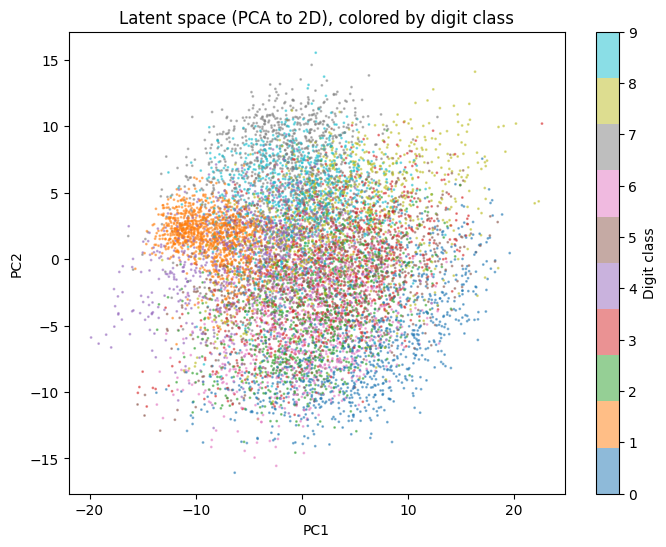

In [10]:
# visualize latent space

# get latent representations for all test images
test_dataset = torchvision.datasets.MNIST(
    root = './data_mnist', train = False, download = True, transform = transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size = 256)

all_latents = []
all_labels = []

model.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        _, latent = model(imgs.to(device))
        all_latents.append(latent.cpu())
        all_labels.append(labels)

all_latents = torch.cat(all_latents).numpy()
all_labels = torch.cat(all_labels).numpy()

print(f"Latent shape: {all_latents.shape}")

# reduce to 2D with PCA for visualization
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)
latents_2d = pca.fit_transform(all_latents)

plt.figure(figsize = (8, 6))
scatter = plt.scatter(latents_2d[:, 0], latents_2d[:, 1],
                      c = all_labels, cmap = 'tab10', alpha = 0.5, s = 1)
plt.colorbar(scatter, label = 'Digit class')
plt.title('Latent space (PCA to 2D), colored by digit class')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

## Day 3 Key Concepts

**Autoencoder**: network trained to compress input -> reconstruct input. No labels needd, input serves as its own target.

**Encoder**: maps high-dimensional input to a small latent representation (the bottleneck)

**Decoder**: reconstructs the original input from the latent representation

**Latent space**: the compressed representation learned by the encoder. Captures the most important structure in the data. Key insight: similar inputs cluster together in latent space even without any label supervision.

**nn.Sequential**: container for running layers in sequence, cleaner than writing x = layer(x) for each layer

**x.view(batch, -1)**: flattens all dimension except batch into one vector, converts (batch, 1, 28, 28) into (batch, 784)

**model.eval()**: switches model to evaluation mode, important habut even when not using dropout/batchnorm

**torch.no_grad()**: disables gradient tracking during inference/visualization, saves memory and speeds things up

**Connection to project**: MultiVI is a VAE, an autoencoder where the latent space is probabilitic rather than deterministic.